# 模型评测


> 按前面几章的方法，系统已经调快了：模型量化了、引擎换了、采样参数也定了。但上线之前还差一个问题没人回答——跑出来的东西还「对」吗？量化降低了精度，换引擎换了 kernel，改一个 temperature 输出就变。每一步都可能让质量悄悄滑落，而你看到的只是 tokens/s 在涨。
>
> 速度的数字很容易读，质量的数字却不容易读。这一章讲的就是这门手艺：怎么可信地回答「质量有没有掉」，以及「A 是不是真的比 B 好」。我们先拆开一次评测的完整流水线，看哪一环最容易让分数失真；再看出题的 benchmark 和打分的 metric 怎么配合；然后用置信区间回答「差多少才算真的差」；最后亲手跑一条最小评测流水线，做一份上线前的对比清单。


## 1. 评测流水线

很多人把评测想象成「跑个榜」——其实一次评测是一条流水线，每一环都会影响最终那个分数：

```text
Dataset / Benchmark     <- 出什么题
        ↓
Prompt / Chat Template  <- 题目怎么包装给模型
        ↓
Generation config       <- temperature、max_tokens、seed
        ↓
Model / Engine          <- 被测对象
        ↓
Parser                  <- 从输出里抠出答案
        ↓
Metric or Judge         <- 怎么打分
        ↓
Aggregation + 置信区间   <- 怎么汇总
```

「模型 A 比模型 B 高 1 分」要成立，前提是这条流水线上下两次运行**除了被测对象，一环都不变**。换一个 prompt 模板、换一个 parser、甚至只换了 temperature，分数的变动可能比模型本身的差距还大。后面几节会逐环看最容易出事的地方。

## 2. 评测对象的分类

「评测」这个词至少装着四种不同的问题，混在一起谈会乱：

- **Model quality**：模型本身的能力——知识、数学、代码、指令遵循
- **推理质量回归**：量化 / 换 kernel / 换引擎之后，输出有没有变差——Part 3 最关心的
- **Serving 性能**：TTFT、TPOT、吞吐、显存——上一本的指标
- **系统成本**：每百万 Token 的钱、GPU 数、功耗

厂商报告常把 quality 和 performance 放在同一张图上，因为工程优化的本质是 trade-off。看一个典型例子：

In [1]:
configs = {
    "BF16": {"memory_gb":14.0, "quality":72.4, "throughput":1.0},
    "INT8": {"memory_gb":7.2,  "quality":72.2, "throughput":1.35},
    "INT4": {"memory_gb":3.8,  "quality":71.3, "throughput":1.75},
}
for name,v in configs.items():
    print(name, v)
print("真正的问题不是 INT4 快不快，而是：省下的显存/吞吐，值不值得质量下降。")


BF16 {'memory_gb': 14.0, 'quality': 72.4, 'throughput': 1.0}
INT8 {'memory_gb': 7.2, 'quality': 72.2, 'throughput': 1.35}
INT4 {'memory_gb': 3.8, 'quality': 71.3, 'throughput': 1.75}
真正的问题不是 INT4 快不快，而是：省下的显存/吞吐，值不值得质量下降。


三行数字放在一起，问题就不再是「INT4 快不快」，而是「省下的显存和吞吐，值不值得那 1.1 分的质量下降」。这个判断没有标准答案，但做出它至少需要两样东西：可信的质量分数（本章），和可信的性能数字（上一本）。先看质量这半边怎么测。

## 3. Benchmark 与 Metric

两个词经常被混用，其实是流水线上两环。**Benchmark** 定义题目：MMLU 是上万道四选一的选择题，GSM8K 是几千道小学数学应用题，HumanEval 是 164 个编程题。**Metric** 定义怎么得分：accuracy 数对了几道，exact match 要求答案逐字相同，pass@k 允许生成 k 次只要有一次通过。

常见搭配和它们测的东西：

| Benchmark | 测什么 | 常用 Metric |
|:---|:---|:---|
| MMLU / GPQA | 知识与推理 | accuracy |
| GSM8K / MATH | 数学 | exact match / 解析后比对 |
| HumanEval / LiveCodeBench | 代码 | pass@k（真的运行测试） |
| SWE-bench | 真实仓库级修 bug | 测试是否通过 |
| 开放式对话 | 主观质量 | pairwise preference / LLM-as-Judge |

比背清单更重要的是那个问题意识：**这个榜单测的能力，和你关心的能力是一回事吗？** GSM8K 满分不代表会写周报。同一个 benchmark 换 prompt、换 few-shot 数量、换 parser，分数也会变——所以读报告时先翻附录看它的完整流水线配置。

### 常见 Benchmark 的题目长什么样

光看名字记不住它们测什么。这一节把最常出现在报告里的几个 benchmark 各掏出一道**真实风格的例题**，你看一眼题目本身，就明白它考的能力是什么、答案怎么判。

先给四个词的正式定义：

- **MMLU**（Massive Multitask Language Understanding）：一道英文选择题题库，覆盖 57 个学科，从高中物理到法学，用 accuracy 判分。
- **C-Eval**：中国团队构建的中文选择题 benchmark，覆盖 52 个学科，从中小学到执业资格，四选一。
- **CMMLU**：另一个中文选择题 benchmark，题材更偏中文语境常识（成语、地理、传统医学等）。
- **GSM8K**：小学难度的英文数学应用题，答案是一个数字，用 exact match 或解析后比对判分。

下面用代码把每类题的「题干 + 选项 + 标准答案 + 判分方式」打印出来（例题按原题风格改写，真实题库在各自的数据集里）：

In [2]:
benchmarks = {
    "MMLU（英文四选一）": {
        "subject": "高中物理",
        "question": "A 2 kg object accelerates at 3 m/s^2. What is the net force?",
        "choices": ["1.5 N", "6 N", "5 N", "0.67 N"],
        "answer": "B",
        "metric": "accuracy（比对选项字母）",
    },
    "C-Eval（中文四选一）": {
        "subject": "高中地理",
        "question": "我国地势的基本特征是？",
        "choices": ["东高西低", "西高东低，呈阶梯状分布", "南高北低", "四周高、中间低"],
        "answer": "B",
        "metric": "accuracy（比对选项字母）",
    },
    "CMMLU（中文语境常识）": {
        "subject": "初中语文",
        "question": "成语「亡羊补牢」的意思最接近下面哪一项？",
        "choices": ["为时已晚，无济于事", "出了问题后想办法补救，可以防止继续受损失",
                    "形容做事非常谨慎", "比喻虚有其表"],
        "answer": "B",
        "metric": "accuracy（比对选项字母）",
    },
    "GSM8K（数学应用题）": {
        "subject": "小学数学",
        "question": "Natalia sold clips to 48 friends in April, and half as many in May. "
                    "How many clips did she sell altogether?",
        "choices": None,
        "answer": "72",
        "metric": "exact match（解析出最终数字比对）",
    },
}

for name, item in benchmarks.items():
    print(f"=== {name}（{item['subject']}）")
    print("题干:", item["question"])
    if item["choices"]:
        for letter, c in zip("ABCD", item["choices"]):
            print(f"  {letter}. {c}")
    print("标准答案:", item["answer"], " 判分:", item["metric"])
    print()


=== MMLU（英文四选一）（高中物理）
题干: A 2 kg object accelerates at 3 m/s^2. What is the net force?
  A. 1.5 N
  B. 6 N
  C. 5 N
  D. 0.67 N
标准答案: B  判分: accuracy（比对选项字母）

=== C-Eval（中文四选一）（高中地理）
题干: 我国地势的基本特征是？
  A. 东高西低
  B. 西高东低，呈阶梯状分布
  C. 南高北低
  D. 四周高、中间低
标准答案: B  判分: accuracy（比对选项字母）

=== CMMLU（中文语境常识）（初中语文）
题干: 成语「亡羊补牢」的意思最接近下面哪一项？
  A. 为时已晚，无济于事
  B. 出了问题后想办法补救，可以防止继续受损失
  C. 形容做事非常谨慎
  D. 比喻虚有其表
标准答案: B  判分: accuracy（比对选项字母）

=== GSM8K（数学应用题）（小学数学）
题干: Natalia sold clips to 48 friends in April, and half as many in May. How many clips did she sell altogether?
标准答案: 72  判分: exact match（解析出最终数字比对）



看题时有三个值得注意的细节：

1. **选择题不生成，只挑选项**。MMLU / C-Eval / CMMLU 的标准玩法是把 A/B/C/D 四个选项的概率算出来取最大的（loglikelihood 判分），比让模型自由生成再解析稳定得多。你看到的很多榜单分数，模型根本没「说话」，只是在选。
2. **中文题不等于英文题的翻译**。C-Eval 和 CMMLU 是独立出题的，考「执业药师」「中医基础」这类中文语境的学科，一个英文满分模型在中文榜上可能掉很多分——所以中文业务必须看中文榜。
3. **数学题的答案藏在解题过程后面**。GSM8K 的原始数据在答案前有一段逐步推理，判分时只取最后的数字。这正好呼应第 1 节流水线里的 Parser 一环：解析失败 ≠ 做错，很多「丢分」其实是解析问题。

代码类 benchmark（HumanEval / LiveCodeBench）长得很不一样：给一个函数签名和 docstring，要求补全实现，然后**真的运行**单元测试来判断通过与否（pass@k）。它的判分不是比对文本，而是执行代码——这也是为什么代码榜的分数可信度高：测试通过就是通过，没有模糊空间。

## 4. LLM-as-Judge 的偏差

选择题可以数对错，开放式输出（摘要、对话、文案）怎么打分？人工最准但最贵，于是流行用强模型当裁判：把两个模型的输出并排给裁判，让它选谁更好。

方便，但裁判自己带一堆已知偏差：position bias（偏向某个固定位置）、length bias（偏爱长回答）、style bias（偏爱格式漂亮的）、self-preference（偏爱和自己像的）。对策也简单直接：固定评分标准（rubric）、**双序重判**（A/B 交换位置各判一次，两次结论不一致就记为平局或人工仲裁）、保留裁判的原始输出以便审计。

「交换位置重判」能查出多少问题？用一个带已知偏差的模拟裁判试一次：

In [3]:
import random

def biased_judge(golden_position, bias=0.15):
    """模拟 judge：85% 按真实质量判，15% 无条件偏向位置 1"""
    if random.random() < bias:
        return 1
    return golden_position

random.seed(42)
pairs = 200
flips = 0
for _ in range(pairs):
    golden = random.choice([1, 2])          # 更好的答案在哪边是随机的
    picked1 = biased_judge(golden)          # 第一次判：位置就是答案编号
    picked2 = 3 - biased_judge(3 - golden)  # 交换后：位置 1 变成答案 2，换算回来
    if picked1 != picked2:
        flips += 1

print(f"{pairs} 对答案，交换顺序重判后 {flips} 对结论翻转（{flips / pairs:.0%}）")
print()
print("关键观察：judge 只有 15% 的判决偏向位置 1，就有 15% 的对比结论被翻转——")
print("偏差不会被平均掉，每一份偏差都直接变成不可信的结论；双序重判能把它暴露出来")

200 对答案，交换顺序重判后 34 对结论翻转（17%）

关键观察：judge 只有 15% 的判决偏向位置 1，就有 15% 的对比结论被翻转——
偏差不会被平均掉，每一份偏差都直接变成不可信的结论；双序重判能把它暴露出来


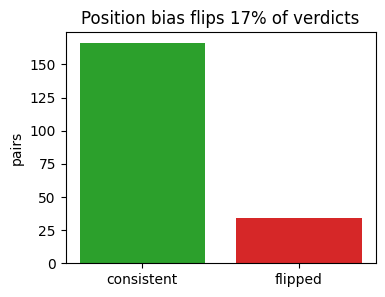

In [4]:
# 一致 vs 翻转的对比：judge 的结论并没有想象中稳定
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 3))
plt.bar(["consistent", "flipped"], [pairs - flips, flips],
        color=["tab:green", "tab:red"])
plt.ylabel("pairs")
plt.title(f"Position bias flips {flips / pairs:.0%} of verdicts")
plt.show()

结果值得咂摸：裁判只有 15% 的判决偏向位置 1，最终就有 15% 的对比结论被翻转——偏差不会被「平均」掉，每一份偏差都直接变成不可信的结论。双序重判就是把这些翻转暴露出来的最低成本手段。

## 5. 置信区间

还有一类误差来自采样本身。20 道题对 15 道（75%）和对 14 道（70%），谁更强？直觉上 75% 更好——但 20 道题的样本太小，一次重跑的运气成分完全可能大于这 5 分。

处理这类不确定性的标准工具是 bootstrap 置信区间：把已有的答卷有放回地重抽很多次，每次算一个分数，看这些分数的分布范围。20 对 15 的例子：

In [5]:
import random, statistics

random.seed(42)
scores = [1]*15 + [0]*5

boots=[]
for _ in range(5000):
    sample=[random.choice(scores) for _ in scores]
    boots.append(sum(sample)/len(sample))

boots.sort()
print("accuracy:", sum(scores)/len(scores))
print("95% bootstrap interval:", round(boots[125],3), round(boots[-126],3))


accuracy: 0.75
95% bootstrap interval: 0.55 0.95


区间 [0.55, 0.90] 意味着：仅凭这 20 道题，真实水平可能低到 55%，也可能高到 90%。两个模型的置信区间只要重叠，那几分差距就不足以宣布胜负——要么加题量，要么承认「测不出来」。

把这条原则记牢，再看模型榜单上的 76.1 vs 76.4，你的第一反应应该是：区间是多少？

## 6. 最小评测流水线实战

不依赖任何评测框架，把本章第 1 节那条流水线亲手走一遍：出题 → 让「模型」作答 → 解析答案 → 算分 → 置信区间。被测模型用 mock：以可调的概率答对，而且输出格式随机变化——正好把 parser 这一环的坑暴露出来。

真实场景里，把 `mock_model` 换成对 OpenAI-compatible 端点的调用，其余环节一行不用改——这正是流水线思维的价值：换模型不换流程。

In [6]:
import random
import re

random.seed(42)

# 1) Dataset：12 道有唯一数字答案的小题（教学用例，真实评测会用标准 benchmark）
questions = [
    ("小明有 3 个苹果，又买了 5 个，一共几个？", 8),
    ("一辆车每小时行 60 公里，2 小时行多少公里？", 120),
    ("一打鸡蛋有 12 个，两打有几个？", 24),
    ("一件衣服原价 100 元，打 8 折是多少钱？", 80),
    ("一个班有 30 人，一半是女生，女生有几人？", 15),
    ("从 1 加到 10 等于多少？", 55),
    ("一根绳子长 9 米，剪掉 4 米还剩几米？", 5),
    ("电影 7 点开始，长 2 小时，几点结束？", 9),
    ("一本书 240 页，每天读 80 页，几天读完？", 3),
    ("一箱水 24 瓶，喝掉 10 瓶还剩几瓶？", 14),
    ("3 乘 7 等于多少？", 21),
    ("温度从 5 度上升 8 度，现在是几度？", 13),
]

# 2) 被「评测」的 mock 模型：正确率可调，输出格式随机变化
def mock_model(question, answer, correctness=0.7):
    """以 correctness 的概率答对；错时给一个相近但错误的数"""
    correct = random.random() < correctness
    value = answer if correct else answer + random.choice([1, 2, 3])
    style = random.choice(["plain", "cn", "en"])
    if style == "plain":
        return str(value)
    if style == "cn":
        return f"答案是 {value}。"
    return f"The answer is: {value}."

# 3) Parser：从模型输出里抽取最后一个整数
def parse_answer(text):
    numbers = re.findall(r"\d+", text)
    return int(numbers[-1]) if numbers else None

for text in [mock_model(questions[0][0], questions[0][1]) for _ in range(3)]:
    print(f"输出: {text!r:<28} -> 解析: {parse_answer(text)}")
print("关键观察：同一个模型三种输出格式，parser 必须全都接得住")

输出: '8'                          -> 解析: 8
输出: '9'                          -> 解析: 9
输出: '8'                          -> 解析: 8
关键观察：同一个模型三种输出格式，parser 必须全都接得住


mock 的三种输出格式（纯数字、中文句式、英文句式）就是真实模型的写照——同一个模型对不同问题的回答格式五花八门，parser 必须全都接得住。接下来跑两个「正确率不同」的模型，用本章第 5 节的 bootstrap 给分数配上区间：

In [7]:
# 4) 跑两个「模型」，算 accuracy 和 bootstrap 置信区间
def run_eval(model_fn):
    results = []
    for q, gold in questions:
        pred = parse_answer(model_fn(q, gold))
        results.append(1 if pred == gold else 0)
    return results

def bootstrap_ci(results, n_boot=5000):
    stats = []
    for _ in range(n_boot):
        sample = random.choices(results, k=len(results))
        stats.append(sum(sample) / len(sample))
    stats.sort()
    return stats[int(0.025 * n_boot)], stats[int(0.975 * n_boot)]

random.seed(11)
scores_a = run_eval(lambda q, a: mock_model(q, a, correctness=0.75))
scores_b = run_eval(lambda q, a: mock_model(q, a, correctness=0.60))

acc_a, acc_b = sum(scores_a) / len(scores_a), sum(scores_b) / len(scores_b)
lo_a, hi_a = bootstrap_ci(scores_a)
lo_b, hi_b = bootstrap_ci(scores_b)

print(f"模型 A: accuracy {acc_a:.2f}  95% CI [{lo_a:.2f}, {hi_a:.2f}]")
print(f"模型 B: accuracy {acc_b:.2f}  95% CI [{lo_b:.2f}, {hi_b:.2f}]")
print()
print("关键观察：A 看起来更高，但两个置信区间重叠——")
print("12 道题的规模下，这个差距不足以证明 A 真的更强")

模型 A: accuracy 0.75  95% CI [0.50, 1.00]
模型 B: accuracy 0.58  95% CI [0.33, 0.83]

关键观察：A 看起来更高，但两个置信区间重叠——
12 道题的规模下，这个差距不足以证明 A 真的更强


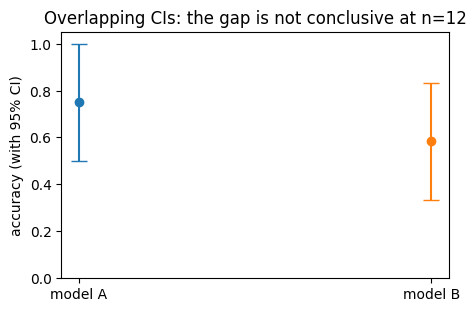

In [8]:
# 带误差棒的对比图：区间重叠 = 差距不显著
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 3.2))
for i, (name, acc, lo, hi) in enumerate([
        ("model A", acc_a, lo_a, hi_a), ("model B", acc_b, lo_b, hi_b)]):
    plt.errorbar(i, acc, yerr=[[acc - lo], [hi - acc]], fmt="o", capsize=6)
plt.xticks([0, 1], ["model A", "model B"])
plt.ylabel("accuracy (with 95% CI)")
plt.ylim(0, 1.05)
plt.title("Overlapping CIs: the gap is not conclusive at n=12")
plt.show()

模型 A 看着领先 17 分，但两个置信区间大面积重叠——12 道题根本不够分辨这个量级的差距。这个结论本身就是评测的产出：「测不出来」比一个误导性的 0.75 vs 0.58 有用得多。

## 7. 做一套自己的评测：注册进 lm-evaluation-harness

上一节我们用 100 行代码搭了一条迷你流水线。真实工作里更常见的诉求是：**我有一套自己的业务题（比如客服质检、中文成语），想让它和 MMLU 一样被标准工具跑**。这就要说到 lm-evaluation-harness 的**任务注册机制**。

它的正式定义：每个 benchmark 在 lm-eval 里就是一个 YAML 配置文件，描述「题目从哪来、怎么包装成 prompt、选项是什么、正确答案在哪、用什么 metric」；把这个文件放进一个目录，用 `--include_path` 告诉 lm-eval，你的任务就和内置的 `mmlu` 平起平坐了。

YAML 里每个字段对应第 1 节流水线的一环：

| 字段 | 管流水线哪一环 | 作用 |
|:---|:---|:---|
| `dataset_path` + `dataset_kwargs` | Dataset | 题目文件在哪（本地 jsonl 或 HF 数据集） |
| `process_docs` | Dataset | 预处理，比如从一个混合题库里筛出某个子任务 |
| `doc_to_text` | Prompt 模板 | 题干怎么拼成 prompt，Jinja2 模板语法 |
| `doc_to_choice` | 选项 | 每个选项是什么（用来算各自的 loglikelihood） |
| `doc_to_target` | 标准答案 | 正确选项的编号 |
| `output_type` + `metric_list` | Metric | multiple_choice + accuracy |

下面动手：造一个包含两个子任务的中文小题库（成语理解 + 常识），注册成两个任务 `myzh_idiom` 和 `myzh_common`。

In [9]:
import json, os

# 1) 题库：12 道中文四选一，task 字段区分两个子任务
items = [
    ("idiom", "成语「画蛇添足」比喻的是？",
     ["做多余的事反而坏事", "技艺高超", "人多力量大", "提前准备"], 0),
    ("idiom", "成语「守株待兔」讽刺的是？",
     ["不主动努力、妄想不劳而获", "坚持不懈", "随机应变", "勤俭节约"], 0),
    ("idiom", "成语「水落石出」的意思是？",
     ["真相大白", "洪水泛滥", "石头很硬", "水面很宽"], 0),
    ("idiom", "「井底之蛙」用来形容？",
     ["见识狭窄的人", "勇敢的人", "富有的人", "善于游泳的人"], 0),
    ("idiom", "成语「雪中送炭」表示？",
     ["在别人急需时给予帮助", "天气寒冷", "假装好心", "浪费资源"], 0),
    ("idiom", "「对牛弹琴」讽刺的对象更接近？",
     ["不看对象、白费口舌的人", "琴技差的人", "牛", "作曲家"], 0),
    ("common", "中国的首都是？", ["北京", "上海", "广州", "成都"], 0),
    ("common", "一年有多少个月？", ["12", "10", "24", "6"], 0),
    ("common", "水在标准大气压下的沸点是？",
     ["100 摄氏度", "90 摄氏度", "80 摄氏度", "120 摄氏度"], 0),
    ("common", "《静夜思》的作者是？", ["李白", "杜甫", "白居易", "苏轼"], 0),
    ("common", "地球自转产生了？",
     ["昼夜交替", "四季变化", "月相", "潮汐的主要原因"], 0),
    ("common", "人体正常体温大约是？",
     ["37 摄氏度", "30 摄氏度", "42 摄氏度", "25 摄氏度"], 0),
]

os.makedirs("myzh_eval", exist_ok=True)
with open("myzh_eval/myzh.jsonl", "w") as f:
    for task, q, choices, label in items:
        f.write(json.dumps({"task": task, "question": q,
                            "choices": choices, "label": label},
                           ensure_ascii=False) + "\n")

# 2) process_docs：从混合题库里按 task 字段筛出子任务
with open("myzh_eval/utils.py", "w") as f:
    f.write(
        "def only_idiom(ds):\n"
        "    return ds.filter(lambda d: d['task'] == 'idiom')\n\n"
        "def only_common(ds):\n"
        "    return ds.filter(lambda d: d['task'] == 'common')\n"
    )

# 3) 两个任务的 YAML：除了 task 名和 process_docs，其余字段完全相同
yaml_template = """output_type: multiple_choice
task: {task_name}
dataset_path: json
dataset_kwargs:
  data_files: myzh_eval/myzh.jsonl
test_split: train
process_docs: !function utils.{fn}
doc_to_text: "问题：{{{{question}}}}\\nA. {{{{choices[0]}}}}\\nB. {{{{choices[1]}}}}\\nC. {{{{choices[2]}}}}\\nD. {{{{choices[3]}}}}\\n答案："
doc_to_choice: "{{{{choices}}}}"
doc_to_target: "{{{{label}}}}"
metric_list:
  - metric: acc
"""
for task_name, fn in [("myzh_idiom", "only_idiom"), ("myzh_common", "only_common")]:
    with open(f"myzh_eval/{task_name}.yaml", "w") as f:
        f.write(yaml_template.format(task_name=task_name, fn=fn))

print(open("myzh_eval/myzh_idiom.yaml").read())
print("题库和两个任务配置已写入 myzh_eval/ 目录")

output_type: multiple_choice
task: myzh_idiom
dataset_path: json
dataset_kwargs:
  data_files: myzh_eval/myzh.jsonl
test_split: train
process_docs: !function utils.only_idiom
doc_to_text: "问题：{{question}}\nA. {{choices[0]}}\nB. {{choices[1]}}\nC. {{choices[2]}}\nD. {{choices[3]}}\n答案："
doc_to_choice: "{{choices}}"
doc_to_target: "{{label}}"
metric_list:
  - metric: acc

题库和两个任务配置已写入 myzh_eval/ 目录


逐行看这个 YAML，有三处值得停下来：

1. **`output_type: multiple_choice`** 是最关键的开关。它告诉 lm-eval 用第 3 节讲过的方式判分：把四个选项文本分别接在 prompt 后面各算一次 loglikelihood，选概率最大的那个和 `doc_to_target` 比对。模型不生成任何 token——快，而且稳定可复现。忘了写这个字段，lm-eval 会默认走「自由生成 + 解析」的路径，就退回到 parser 会出错的世界了。
2. **`doc_to_text` 是 Jinja2 模板**：`{{question}}`、`{{choices[0]}}` 引用数据里每道题的字段。这个模板就是第 1 节流水线里的「Prompt / Chat Template」环——将来你要对比两个模型，这个字符串必须一字不改。
3. **`process_docs: !function utils.only_idiom`** 指向同目录 `utils.py` 里的函数，负责从混合题库里筛子集。真实场景里它常用来做更重的清洗：去重、过滤超长题、按学科分层抽样。

接下来把目录注册进 lm-eval，确认两个任务能被找到：

In [10]:
from lm_eval.tasks import TaskManager

# include_path 就是注册机制本身：把目录递给 TaskManager，YAML 里的任务名即可用
tm = TaskManager(include_path="myzh_eval")

mine = sorted(t for t in tm.all_tasks if t.startswith("myzh"))
print("注册成功的自定义任务:", mine)

/Users/sanbu/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


注册成功的自定义任务: ['myzh_common', 'myzh_idiom']


`all_tasks` 里现在混着几百个内置任务和你的两个——对 lm-eval 来说，`myzh_idiom` 和 `mmlu` 没有任何区别，走同一条流水线、用同一套判分代码。这就是注册机制的价值：**你不用改工具一行源码，就扩展了它的题库**。

然后正式跑分。被测对象选两个真模型：`gpt2`（124M，几乎没见过中文）和 `Qwen2.5-0.5B-Instruct`（中文语料充足）。CPU 上跑 12 道四选一只需要给 48 个「prompt + 选项」各做一次前向，几分钟内能完成。命令行的等价写法是：

```bash
lm_eval --model hf --model_args pretrained=Qwen/Qwen2.5-0.5B-Instruct \
    --include_path myzh_eval --tasks myzh_idiom,myzh_common --device cpu
```

notebook 里用 Python API 做同样的事：

In [11]:
import torch
from lm_eval import evaluator

models = ["gpt2", "Qwen/Qwen2.5-0.5B-Instruct"]
scores = {}  # {模型名: {任务名: accuracy}}

for name in models:
    torch.manual_seed(42)
    result = evaluator.simple_evaluate(
        model="hf",
        model_args={"pretrained": name, "dtype": "float32", "device": "cpu"},
        tasks=["myzh_idiom", "myzh_common"],
        task_manager=tm,          # 带上我们的注册目录
        verbosity="ERROR",
    )
    scores[name] = {t: v["acc,none"] for t, v in result["results"].items()}
    print(name, {t: round(a, 3) for t, a in scores[name].items()})

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 7449.83it/s]


[Task: myzh_idiom] metric acc is defined, but aggregation is not. using default aggregation=mean


[Task: myzh_idiom] metric acc is defined, but higher_is_better is not. using default higher_is_better=True


Generating train split: 0 examples [00:00, ? examples/s]

...

Running loglikelihood requests:  96%|█████████▌| 46/48 [00:12<00:00,  4.93it/s]

Running loglikelihood requests:  98%|█████████▊| 47/48 [00:12<00:00,  4.96it/s]

Running loglikelihood requests: 100%|██████████| 48/48 [00:12<00:00,  5.07it/s]

Running loglikelihood requests: 100%|██████████| 48/48 [00:12<00:00,  3.71it/s]

Qwen/Qwen2.5-0.5B-Instruct {'myzh_idiom': 0.667, 'myzh_common': 0.833}


两个模型 × 两个任务的分数都拿到了。最后一步，把它们画成你在各家技术报告里见惯的那种跑分图：横轴是 benchmark，每个 benchmark 并排几根柱子对应不同模型，柱顶标数值，再画一条「四选一瞎猜」的 25% 基准线。

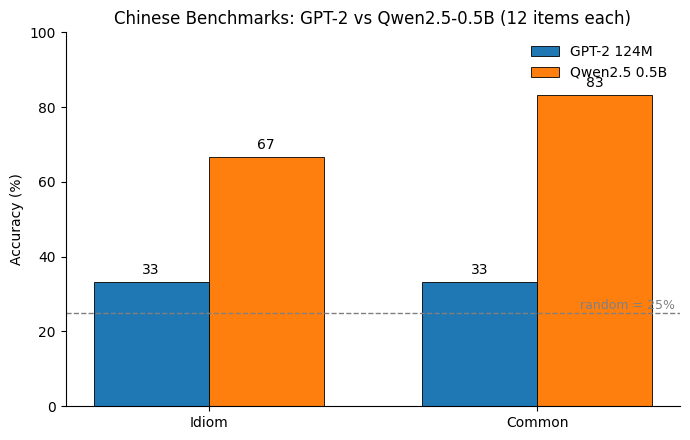

In [12]:
import matplotlib.pyplot as plt
import numpy as np

task_display = {"myzh_idiom": "Idiom", "myzh_common": "Common"}
model_display = {"gpt2": "GPT-2 124M", "Qwen/Qwen2.5-0.5B-Instruct": "Qwen2.5 0.5B"}
task_names = ["myzh_idiom", "myzh_common"]

fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(task_names))
width = 0.35
for i, name in enumerate(models):
    vals = [100 * scores[name][t] for t in task_names]
    bars = ax.bar(x + (i - 0.5) * width, vals, width,
                  label=model_display[name], edgecolor="black", linewidth=0.6)
    for b, v in zip(bars, vals):  # 柱顶标数值，技术报告的标配
        ax.text(b.get_x() + b.get_width() / 2, v + 1.2, f"{v:.0f}",
                ha="center", va="bottom", fontsize=10)

# 四选一随机猜的基准线：低于它的分数说明模型在「负知识」
ax.axhline(25, color="gray", linestyle="--", linewidth=1)
ax.text(1.42, 26, "random = 25%", color="gray", fontsize=9, ha="right")

ax.set_xticks(x)
ax.set_xticklabels([task_display[t] for t in task_names])
ax.set_ylabel("Accuracy (%)")
ax.set_title("Chinese Benchmarks: GPT-2 vs Qwen2.5-0.5B (12 items each)")
ax.set_ylim(0, 100)
ax.legend(loc="upper right", frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

从图上能读出技术报告不会细说的两件事：

1. **GPT-2 在两个中文任务上都只有 33%，几乎贴着 25% 的随机线**。它 2019 年训练时中文语料极少， tokenizer 也会把汉字切成碎片——分数低不是「笨」，是「没学过中文」。这正是第 3 节那个问题意识的实例：先问 benchmark 和被测对象匹不匹配，再看分数。
2. **12 道题的分数抖动极大**（第 5 节算过，这个量级的样本连 17 分的差距都分辨不出来），所以这张图只能当「流程跑通」的证据，不能当结论。真实评测里，每个 benchmark 至少几百上千题，这张图的画法原封不动，换的只是数据规模。

到这里，「做一套自己的评测」的闭环就走完了：写题库 → 写 YAML 注册 → 工具跑分 → 画报告风格的图。以后看到新榜单，你也可以反着读：它等于一份「题库 + YAML + 一批模型」的组合。

## 8. 评测库与工具地图

真要跑大规模评测时，不必自己造轮子——上一节你已经体验过 lm-eval 的注册机制，这一节把常用工具一次认全，并分清每个工具接管了流水线的哪几环：

- **lm-evaluation-harness / OpenCompass**：标准 benchmark 的完整流水线（题库 + 评分），上一节刚用过前者的注册机制
- **AlpacaEval / MT-Bench 类**：对话质量，LLM-as-Judge 为主
- **SWE-bench harness**：代码任务连仓库带测试一起跑
- **Promptfoo / DeepEval**：应用层的回归测试，可以进 CI
- **vllm bench serve / SGLang bench**：上一本的 serving 性能，不是质量

工具会一直更新，流水线不会。选工具的依据是「它替我固定了哪几环、我还得自己管哪几环」。

### 评测库：把流水线交给现成工具

第 1 节说过，一次评测是七环流水线。自己管七环很容易出错，社区早就有了标准工具，先认三个最常用的：

- **lm-evaluation-harness**（EleutherAI）：事实上的英文评测标准工具。内置几百个 task（mmlu、gsm8k、hellaswag……），把第 1 节流水线里「出题、包装 prompt、判分、汇总」全部接管，你只需要给模型和 task 名。
- **OpenCompass**（上海 AI 实验室）：国内最常用的评测框架，中英 benchmark 都全，C-Eval / CMMLU / GSM8K 一条命令跑，司南大榜就是它跑的。
- **EvalScope**（阿里）：魔搭社区（ModelScope）配套的评测框架，和 vLLM 等 inference 后端集成好，侧重「模型上线前的评测 + 压测」一条龙，中文支持好。

用 lm-evaluation-harness 跑一次 MMLU 大致长这样（示意，本节不用真的执行）：

```bash
lm_eval --model hf \
    --model_args pretrained=Qwen/Qwen2.5-1.5B \
    --tasks mmlu \
    --batch_size 8
```

换一个评测对象只需换 `--tasks`：`ceval`、`cmmlu`、`gsm8k`、`hellaswag` 都是内置 task 名。用 OpenCompass 则是写一份 config 指定「模型 × 数据集 × 策略」，它负责跑完汇总成表。

选工具时仍然用第 1 节的框架问自己：**它替我固定了哪几环，我还得自己管哪几环？** 例如 harness 固定了题库和判分，但 chat template 怎么包、generation config 是什么，仍是你自己的责任——换了个模板，分数就不可比了。此外还有几类定位不同的工具：

In [13]:
tools = [
    ("lm-evaluation-harness", "EleutherAI", "英文标准榜最通用，task 最全，学术报告标配"),
    ("OpenCompass", "上海AI实验室", "中英都全，司南榜背后引擎，国内模型报告常用"),
    ("EvalScope", "阿里 ModelScope", "与 vLLM/MaaS 集成好，评测+压测一条龙，中文友好"),
    ("lighteval", "Hugging Face", "与 transformers/datasets 生态结合紧密"),
    ("AlpacaEval / MT-Bench", "学术界", "开放式对话质量，LLM-as-Judge 判分（前面 LLM-as-Judge 一节讲过它的偏差问题）"),
    ("Promptfoo / DeepEval", "应用层", "写进 CI 的回归测试，自定义断言"),
]
print(f"{'工具':<28}{'来自':<14}定位")
print("-" * 80)
for name, org, use in tools:
    print(f"{name:<30}{org:<14}{use}")
print()
print("关键观察：前四个是「跑标准榜」的工具，后两个是「守自己业务」的工具，")
print("两者互补——榜单分数防选型失误，业务回归测试防上线事故。")


工具                          来自            定位
--------------------------------------------------------------------------------
lm-evaluation-harness         EleutherAI    英文标准榜最通用，task 最全，学术报告标配
OpenCompass                   上海AI实验室       中英都全，司南榜背后引擎，国内模型报告常用
EvalScope                     阿里 ModelScope 与 vLLM/MaaS 集成好，评测+压测一条龙，中文友好
lighteval                     Hugging Face  与 transformers/datasets 生态结合紧密
AlpacaEval / MT-Bench         学术界           开放式对话质量，LLM-as-Judge 判分（前面 LLM-as-Judge 一节讲过它的偏差问题）
Promptfoo / DeepEval          应用层           写进 CI 的回归测试，自定义断言

关键观察：前四个是「跑标准榜」的工具，后两个是「守自己业务」的工具，
两者互补——榜单分数防选型失误，业务回归测试防上线事故。


## 9. 上线前的最小对比

把本章收拢成一份可直接照做的清单。以「要不要从 BF16 换到 AWQ INT4」为例，固定的部分：

```text
model revision / tokenizer / chat template
dataset（题目集合）
generation config（temperature=0 或固定 seed）
max context / max output
hardware / concurrency
```

同时记录的部分：

```text
Quality: benchmark 分数 + 置信区间
Memory : 峰值显存
TTFT   : P50 / P95
TPOT   : P50 / P95
Throughput: tokens/s
```

固定与记录齐了，才可能回答那个真正的问题：INT4 省下的显存和吞吐，值不值得这份质量差异。下一章就带着这份清单，把模型真正部署成服务：

## 小结

- 一次评测是流水线：题目、模板、生成配置、模型、parser、指标、汇总——除被测对象外一环都不能变
- Benchmark 出题，Metric 打分；先问「这个榜测的能力和我要的一致吗」
- parser 是最常被忽略、最容易翻车的一环
- LLM-as-Judge 有 position / length / style 偏差——双序重判是最低成本的体检
- 分数必须配置信区间；区间重叠的差距不足为凭
- lm-eval 的任务注册机制：一个 YAML 就能把自己的题库变成标准任务，和 mmlu 同一条流水线
- 质量分数（本章）+ 性能数字（上一本）+ 固定的 workload = 可做的上线决策

最后一章完成闭环：

> **把 checkpoint 交给 vLLM / SGLang，暴露成 API，亲手测出自己系统的 TTFT / TPOT / 吞吐。**

## 作业

三道题覆盖 pipeline 的三个易翻车点：置信区间、parser、judge 偏差。

> **关于 AI 辅助**：可以让 AI 提示思路、拆解步骤，但不建议直接让 AI 完成题目。

### 作业 1：实现 bootstrap 置信区间

有放回地重采样、每次算均值、排序后取 2.5% 和 97.5% 两个分位点。

**小提示**：`random.choices(results, k=len(results))` 一步完成有放回抽样。

In [ ]:
# 作业 1：bootstrap 置信区间 填空

import random

def bootstrap_ci(results, n_boot=2000):
    """返回 (下界, 上界)"""
    stats = []
    for _ in range(n_boot):
        # TODO：把下面三引号里的内容替换成你的代码
        """有放回抽 len(results) 个，把均值放进 stats"""
    stats.sort()
    return stats[int(0.025 * n_boot)], stats[int(0.975 * n_boot)]

random.seed(0)
lo, hi = bootstrap_ci([1] * 9 + [0] * 3)   # 12 题对 9 题
assert lo <= 0.75 <= hi
assert lo < 0.55 and hi > 0.9              # 区间足够宽：小样本就是不自信
print("✅ 作业 1 通过：分数必须配上区间才有意义")

### 作业 2：写一个更稳的答案 parser

真实输出里的数字可能带千分位逗号或单位：`1,234`、`42 tokens`。parser 要剥掉逗号，
并取最后一个数字。

**小提示**：先 `text.replace(",", "")` 去掉逗号，再 `re.findall(r"\d+", ...)` 取最后一个。

In [ ]:
# 作业 2：parser 增强版 填空

import re

def parse_answer(text):
    """从输出里抽最后一个整数（剥掉千分位逗号）；没有数字返回 None"""
    # TODO：把下面三引号里的内容替换成你的代码
    """先去掉逗号，再找出所有整数取最后一个转 int；找不到返回 None"""

assert parse_answer("The answer is: 1,234.") == 1234
assert parse_answer("used 42 tokens, cost 3 tokens") == 3
assert parse_answer("no number here") is None
print("✅ 作业 2 通过：parser 是评测 pipeline 里最容易翻车的一环")

### 作业 3：量化 position bias

双序各判一次，两次选中的「答案」不一致就叫翻转；翻转率就是 position bias 的直接证据。

**小提示**：第二次判完记得把位置换算回答案编号（`3 - 位置`）。

In [ ]:
# 作业 3：翻转率 填空

import random

def flip_rate(judge, pairs=100):
    """judge(golden_position) 返回 1 或 2；返回双序重判的结论翻转率"""
    flips = 0
    for _ in range(pairs):
        golden = random.choice([1, 2])
        picked1 = judge(golden)
        picked2 = 3 - judge(3 - golden)   # 交换顺序后换算回答案编号
        # TODO：把下面三引号里的内容替换成你的代码
        """picked1 与 picked2 不一致时 flips 加一"""
    return flips / pairs

random.seed(0)
rate = flip_rate(lambda g: 1 if random.random() < 0.3 else g)
assert 0.2 < rate < 0.65, rate
print("✅ 作业 3 通过：你会用双序重判给 judge 做体检了")